In [1]:
#
# Transfer line matching
#

from pprint import pprint

import numpy as np
import py4madx as pm

import scipy
# import matplotlib 
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches
# --- they are also imported in the InitPlot.py script below.

import os
if os.uname()[1] == 'pcbe16924':
    %run ~/efthymio-eos/InitPlots.py
else:
    %run /Users/iliasefthymiopoulos/cernbox/InitPlots.py
    
MyPlots().configPlots('')


>>> Running InitPlots.py - Version : 1.02 - 07.03.2023 (IE)
---- running configPlots function 


## Initialisation

In [2]:
import ttline_to_lenustorm as ttline

In [3]:
layout_parameters = {
    'trg_to_lemond'   : 250,
    'l_decay_tunnel'  : 80,
    'w_decay_tunnel'  : 2*6.5,
    'r_decay_pipe'    : 2.0,
    'h_decay_tunnel'  : 2*6.5,
}

ttline_parameters = { # units in [m]
    'l_bend'      : 2.0,  # arc length of the dipoles
    'l_bend_end'  : 0.35,
    
    'l_quad'      : 0.80,
    'l_quad_end'  : 0.20,
    'l_quad_w'    : .60,
    'l_quad_h'    : .60,

    'l_qfl'       : 0.80,
    'l_qfl_end'   : 0.20,
    'l_qfl_w'     : .90,
    'l_qfl_h'     : .90,
    
    'l_vac'       : 0.10,

    'trg_to_d1pivot'     : 4.0,      # from targed front to D1 pivot point
    'd2pivot_to_inj'     : (-2, 4.0),   # D2 pivot to LEnuSTORM injection point in (x,z) coordinates 
    
    'beam_size'  : 0.20,  # +- 10 cm beam size
    'aperture_x' : 0.15,  # 30cm diameter 
    'aperture_y' : 0.15
 }



In [4]:
lenustorm_df = pd.read_parquet('./lenustorm.parquet')
lenustorm_df.head()

,s_fr,element_type,name_fr,isthick,isreplica,parent_name,iscollective,X,Y,Z,...,tilt,X_cm,Y_cm,Z_cm,theta_deg,el_name,model_id,model_name,ishalf,Consecutive_Count
0,0.000000,Drift,D_stoA1,True,False,None,False,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.000000,0.0,D_stoA1.0,None,None,False,1
1,0.994410,Quadrupole,QDS_to_A2,True,False,None,False,0.0,0.0,0.994410,...,0.0,0.0,0.0,99.440964,0.0,QDS2A2.0,QDS_to_A2,qdsa2vol,False,1
2,1.244410,Drift,D_stoA1,True,False,None,False,0.0,0.0,1.244410,...,0.0,0.0,0.0,124.440964,0.0,D_stoA1.1,None,None,False,1
3,2.238819,Quadrupole,QFS_to_A1,True,False,None,False,0.0,0.0,2.238819,...,0.0,0.0,0.0,223.881929,0.0,QFS2A1.0,QFS_to_A1,qfsa1vol,False,1
4,2.488819,Drift,D_stoA1,True,False,None,False,0.0,0.0,2.488819,...,0.0,0.0,0.0,248.881929,0.0,D_stoA1.2,None,None,False,1


## Define Transfer Line Geometry

In [5]:
ttline.TTLINE.build_line_from_angle_and_displacement?

Signature:
ttline.TTLINE.build_line_from_angle_and_displacement(
    angle_deg=-54.0,
    xdisp=-12.5,
    params=None,
    lparams=None,
)
Docstring: <no docstring>
File:      ~/Work/esslenustorm/myanal/ttline_to_lenustorm.py
Type:      method

In [7]:
if 0 : 
    print(f'\n\n TTLINE-A from injection point')
    lineA = ttline.TTLINE.build_line_from_inj_point((-16, 22), ttline_parameters)  # Line through (0,0) and (3,6)
    import json
    # print(json.dumps(lineA.__dict__, indent=4))

print(f'\n\n ==== TTLINE-B from angle, lateral displacement')
lineB = ttline.TTLINE.build_line_from_angle_and_displacement(angle_deg=-30.0, xdisp=-9.5, params=ttline_parameters, lparams=layout_parameters)  # Line at 45 degrees to the x-axis
# print(json.dumps(lineB.__dict__, indent=4))
lineB.display()
pion_gamma = 0.7/0.139
pion_decay_length = 2.6e-8*scipy.constants.c*pion_gamma
print(pion_gamma, pion_decay_length)
print(f' --- TL length ......... {lineB.line_length}[m], {lineB.line_length/pion_decay_length*100:.2f}[%] of decay length ')
print(f' --- Surviving rate .... {np.exp(-lineB.line_length/pion_decay_length)*100:.2f}')



 ==== TTLINE-B from angle, lateral displacement
 build_line_from_angle_and_displacement : angle_deg=-30.0, xdisp=-9.5, params={'l_bend': 2.0, 'l_bend_end': 0.35, 'l_quad': 0.8, 'l_quad_end': 0.2, 'l_quad_w': 0.6, 'l_quad_h': 0.6, 'l_qfl': 0.8, 'l_qfl_end': 0.2, 'l_qfl_w': 0.9, 'l_qfl_h': 0.9, 'l_vac': 0.1, 'trg_to_d1pivot': 4.0, 'd2pivot_to_inj': (-2, 4.0), 'beam_size': 0.2, 'aperture_x': 0.15, 'aperture_y': 0.15, 'd1_angle_deg': -30.0, 'd1_angle': -0.5235987755982988, 'd1_pivot': (0, 4.0), 'd2_pivot': (-9.5, np.float64(20.454482671904337)), 'lenustorm_inj': (-11.5, np.float64(24.454482671904337)), 'method': 'from angle (-30.0[deg]) and lateral displacement (-9.5[m])'}
 l_bend........................ 2.0
 l_bend_end.................... 0.35
 l_quad........................ 0.8
 l_quad_end.................... 0.2
 l_quad_w...................... 0.6
 l_quad_h...................... 0.6
 l_qfl......................... 0.8
 l_qfl_end..................... 0.2
 l_qfl_w.......................

 -- TARGET : xy =0.000, 0  0.0
 -- MB1 : xy =3.931, 0  0.0
 -- QF1 : xy =5.804, -1.0416666666666665  -0.5235987755982988
 -- QD1 : xy =6.959, -1.7083333333333333  -0.5235987755982988
 -- QFL1 : xy =8.114, -2.375  -0.5235987755982988
 -- QD2 : xy =9.268, -3.041666666666667  -0.5235987755982988
 -- QF2 : xy =10.423, -3.7083333333333335  -0.5235987755982988
 -- QF3 : xy =14.031, -5.791666666666667  -0.5235987755982988
 -- QD3 : xy =15.186, -6.458333333333334  -0.5235987755982988
 -- QFL2 : xy =16.341, -7.125000000000001  -0.5235987755982988
 -- QD4 : xy =17.496, -7.791666666666668  -0.5235987755982988
 -- QF4 : xy =18.650, -8.458333333333334  -0.5235987755982988
 -- MB2 : xy =20.523, -9.5  0.0
 -- INJ : xy =24.454, -9.5  0.0


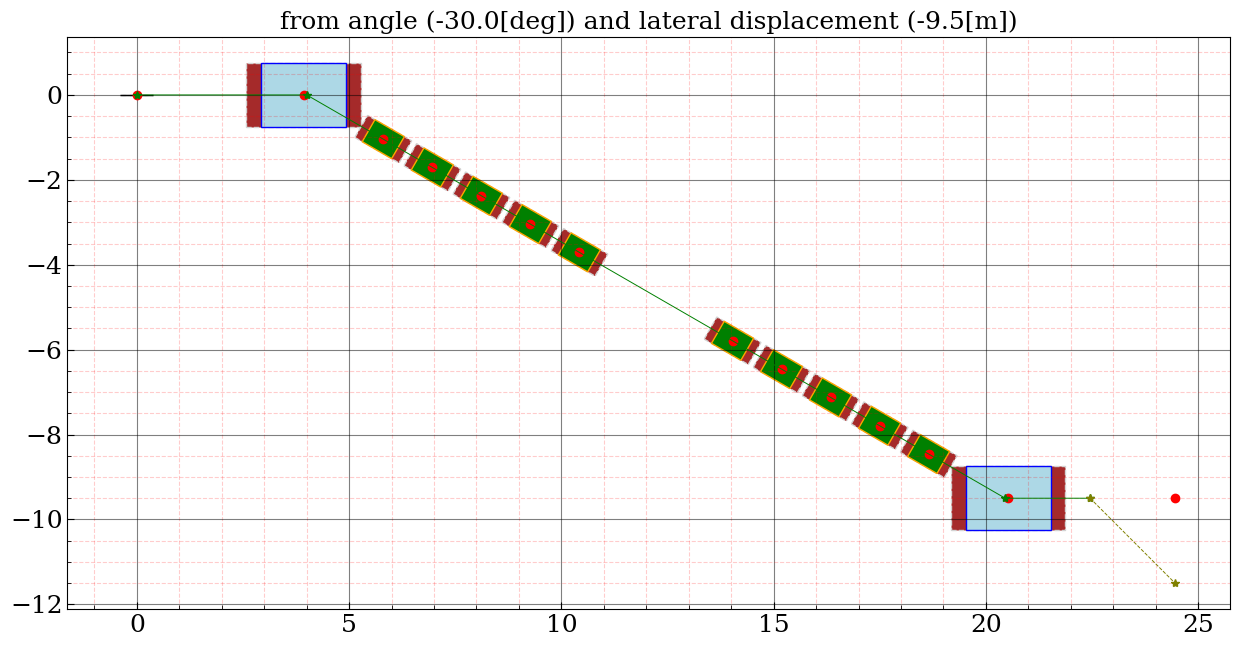

[[ 9.98700419e-01 -5.09654015e-02  2.44544827e+03]
 [ 5.09654015e-02  9.98700419e-01 -1.15000000e+03]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
13446.660415981414 -588.5892075231955 25000


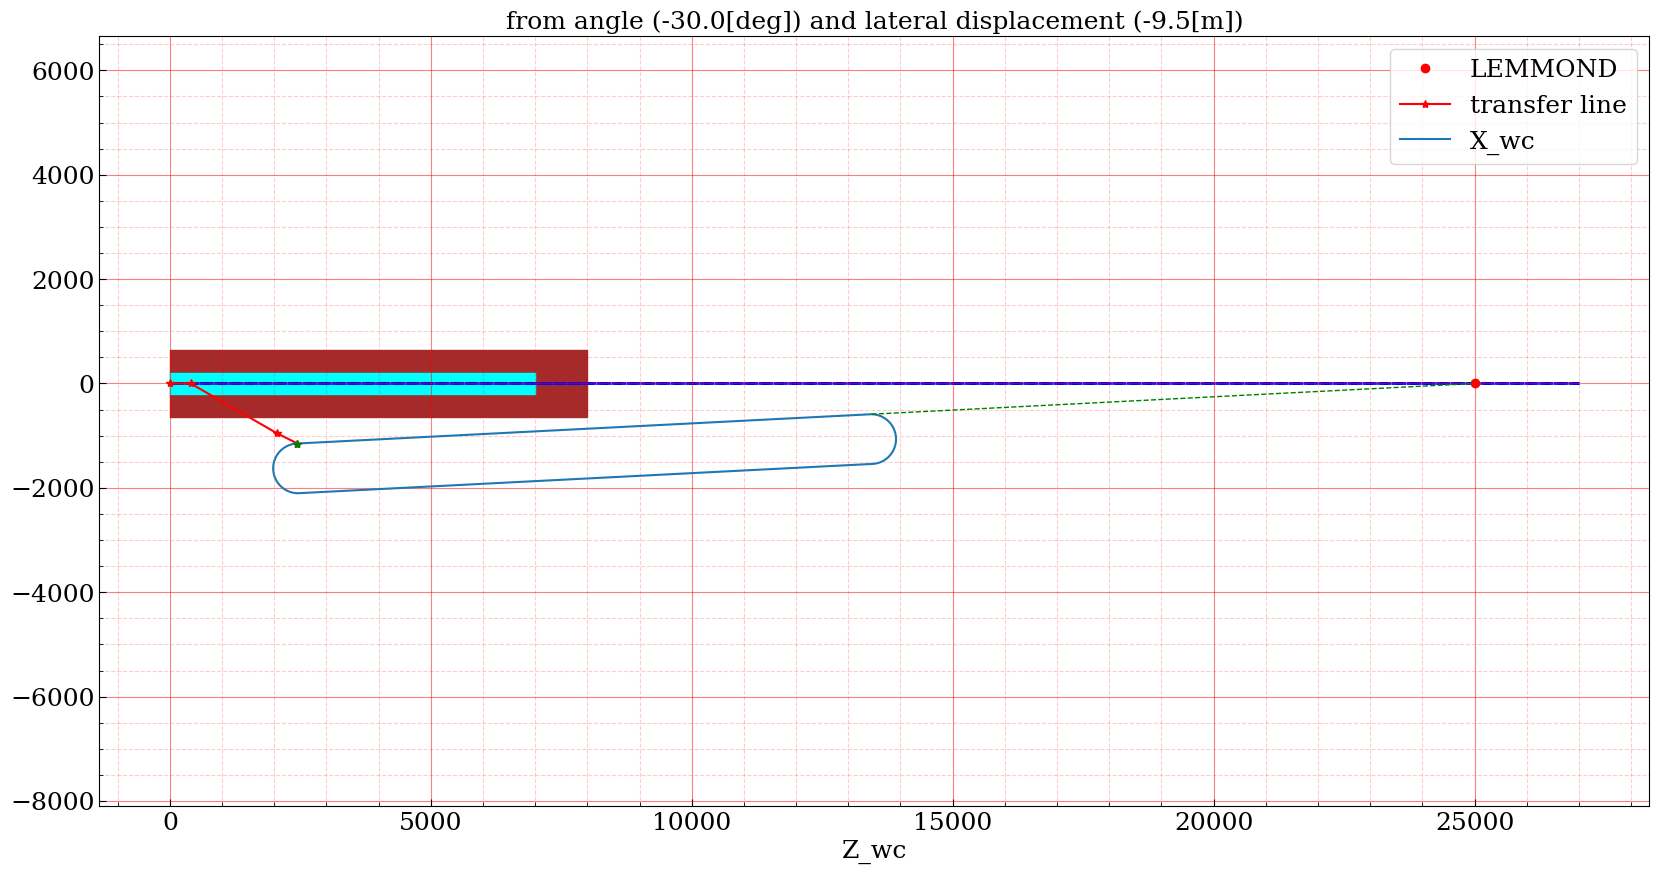

In [8]:
fig = ttline.plot_ttline(lineB)
fig = ttline.plot_layout(lineB,  lenustorm_df, layout_parameters)

## MAD-X for the transfer line

In [ ]:
from cpymad.madx import Madx
madx = Madx()
madx.input(f'''
    option echo, warn, info;
    option, rbarc=false; ! such that the defined length in RBEND is actually the arc length 
''')

In [ ]:
tlelements = lineB.elements
_dfy = pd.DataFrame(tlelements)
_dfy[['coord_x', 'coord_y']] = pd.DataFrame(_dfy['coord'].tolist(), index=_dfy.index)
_dfy = _dfy.set_index('name')
_dfy

In [ ]:
madx.input(f''' 
           
    add_preline = 0;
    
    l.d0 = 2.0;
    l.q0 = 0.8;
    
    d0 : drift, l=l.d0;
    kqf0 := 0.01;
    kqd0 := -0.02;
    kqf1 := 0.01;
    kqd1 := -0.02;
    pqf0 : quadrupole, l=l.q0, K1 :=kqf0;
    pqd0 : quadrupole, l=l.q0/2, k1 :=kqd0;
    pqf1 : quadrupole, l=l.q0, K1 :=kqf1;
    pqd1 : quadrupole, l=l.q0/2, k1 :=kqd1;
    mbd : drift, l=1.0;
    PRELINE: line=(d0, pqf0, d0, pqf1, d0, d0, pqd0, d0, pqd1, d0, mbd);

    kqf := 0.01;
    kqd := -0.01;
    kfl := 0.02;
    
    D1: sbend, l={lineB.l_bend}, angle={abs(lineB.d1_angle)}, e1=0, e2={lineB.d1_angle}, hgap=0.20, fint=0.4;
    D2: sbend, l={lineB.l_bend}, angle={lineB.d1_angle}, e1={lineB.d1_angle}, e2=0, hgap=0.20, fint=0.4;
    MQF : quadrupole, l={lineB.l_quad}, k1 :=kqf;
    MQD : quadrupole, l={lineB.l_quad}, k1 :=kqd;
    MQFL : quadrupole, l={lineB.l_qfl}, k1 :=kfl; 
    
    l.preline = 7*l.d0 + 4*l.q0;
    
    if (add_preline == 1) {{ l.offset = l.preline; }}
    else {{ l.offset = 0; }}
    l.ttline = l.offset + {float(_dfy.iloc[-1].spos)};
    value, l.q0, l.d0, l.preline,l.offset, l.ttline;
        
    ttline : sequence, refer = centre, l=l.ttline;
        target : marker,  at = 0.0;
        if (add_preline == 1){{
            ! --- pre line as defined above
            qfp.1 : qf0, at=l.d0+l.q0/2,               from=target;
            qdp.1 : qd0, at=2*l.d0+l.q0+1/4*l.q0,      from=target;
            qdp.2 : qd0, at=3*l.d0+l.q0+3/4*l.q0,      from=target;
            qfp.2 : qf0, at=4*l.d0+5/2*l.q0,           from=target;
        }}  
        ! --- Actual TT line
        mb1 : D1, at=l.offset+{float(_dfy.loc["MB1"].spos)},       from=target;
        qf1 : MQF, at=l.offset+{float(_dfy.loc["QF1"].spos)},      from=target;
        qd1 : MQD, at=l.offset+{float(_dfy.loc["QD1"].spos)},      from=target;
        qfl1 : MQFL, at=l.offset+{float(_dfy.loc["QFL1"].spos)},   from=target;
        qd2 : MQD, at=l.offset+{float(_dfy.loc["QD2"].spos)},      from=target;
        qf2 : MQF, at=l.offset+{float(_dfy.loc["QF2"].spos)},      from=target;
        qf3 : MQF, at=l.offset+{float(_dfy.loc["QF3"].spos)},      from=target;
        qd3 : MQD, at=l.offset+{float(_dfy.loc["QD3"].spos)},      from=target;
        qfl2 : MQFL, at=l.offset+{float(_dfy.loc["QFL2"].spos)},   from=target;
        qd4 : MQD, at=l.offset+{float(_dfy.loc["QD4"].spos)},      from=target;
        qf4 : MQF, at=l.offset+{float(_dfy.loc["QF4"].spos)},      from=target;
        mb2 : D2, at=l.offset+{float(_dfy.loc["MB2"].spos)},       from=target;
        inj : marker, at=l.ttline,                 from=target;
    endsequence;
''')

### Match preline

In [ ]:
# --- define preline sequence
madx.input(f''' 
    
    beam, particle=proton, pc=0.7;
    use, period=preline;
    
    match, rmatrix, sequence=preline, betx=1.0, bety=1.0, alfx=0.0, alfy=0.0;
        weight, mux=10, muy=10, betx=1, bety=1;
        vary, name=kqf0, step=1.0e-6;
        vary, name=kqd0, step=1.0e-6;
        vary, name=kqf1, step=1.0e-6;
        vary, name=kqd1, step=1.0e-6;
        ! constraint, sequence=preline, range=#e, mux=0.25, muy=0.25;
        constraint, sequence=preline, range=#e, re22=0, re44=0;
        constraint, sequence=preline, range=#e, betx<20, bety<20;

        jacobian, calls=30, tolerance=1.0e-20, bisec=3;
        ! lmdif, calls=2000, tolerance=1.0e-21;
    endmatch;
    
    value, kqf0, kqd0;
''')


In [ ]:
madx.input(f'''
    use, period=preline;       
    select,flag=twiss,clear;
    select,flag=twiss,full, column=name,s,x, y, px, py, betx,bety,alfx,alfy,dx,dpx,mux,muy,RE11,RE12,RE21,RE22,RE33,RE34,RE43,RE44,R16,R26,R36,R46;
    ! select,flag=twiss,column=name,s,x, y, px, py, betx,bety,alfx,alfy,dx,dpx,mux,muy;

    twiss, rmatrix, betx=1, bety=1;
    r11=table(twiss,mbd,Re11);r12=table(twiss,mbd,Re12);
    r21=table(twiss,mbd,Re21);r22=table(twiss,mbd,Re22);
    r33=table(twiss,mbd,Re33);r34=table(twiss,mbd,Re34);
    r43=table(twiss,mbd,Re43);r44=table(twiss,mbd,Re44);
    r16=table(twiss,mbd,Re16);r26=table(twiss,mbd,Re26);
    value, r11, r12, r21, r22, r34, r44;
''')
preline_twdf = madx.table['twiss'].dframe()
preline_twdf['beam'] = 'preline'

In [ ]:
preline_twdf

In [ ]:
fig = ttline.plot_optics(preline_twdf,'preline', title='Pre-line from tearget to D1', ymaxdisp=[-5,5])

### TT line cell matching

In [ ]:
madx.eval('qd1->k1')

In [ ]:
madx.input(f'''
    ! --- remove first QFL to make the match
    cell.1 : marker;
    seqedit, sequence=ttline; remove, element=qfl1; install, element=cell.1, at={float(_dfy.loc["QFL1"].spos)}, from=target; endedit;
    
    beam, particle=proton, pc=0.7;
    use, period=ttline;
    select,flag=twiss,clear;
    select,flag=twiss,column=name,s,betx,bety,alfx,alfy,dx,dpx,mux,muy,RE11,RE12,RE21,RE22,RE33,RE34,RE43,RE44,R16,R26,R36,R46;
    twiss, rmatrix, betx=1, bety=1;
''')
ttline_twdf = madx.table['twiss'].dframe()
ttline_twdf['beam'] = 'ttline'

In [ ]:
ttline_twdf

In [ ]:
madx.input(f'''
kfl = 0;
value, qf1->k1, qd1->k1, qfl2->k1;

use, sequence=ttline;
match, rmatrix, sequence=ttline, betx=1, bety=1;
    ! constraint, sequence=ttline, range=cell.1, mux=0.25, muy=0.25;
    ! constraint, sequence=ttline, range=cell.1, alfx=0.0, alfy=0.0;
    constraint, sequence=ttline, range=cell.1, betx<10.0, bety<10.0;

    vary, name=qf->k1, step=1e-6;
    vary, name=qd->k1, step=1e-6;
    jacobian, calls=20, tolerance=1e-20,bisec=3;
endmatch;

value, tar, qf0->k1, qd0->k1, qf1->k1, qd1->k1;
''')

In [ ]:
madx.input(f'''
    use, period=ttline;
    select,flag=twiss,clear;
    select,flag=twiss,column=name,s,betx,bety,alfx,alfy,dx,dpx,mux,muy,RE11,RE12,RE21,RE22,RE33,RE34,RE43,RE44,R16,R26,R36,R46;
    twiss, rmatrix, betx=1, bety=1;
''')
ttline_twdf = madx.table['twiss'].dframe()
ttline_twdf['beam'] = 'ttline'

In [ ]:
ttline_twdf

In [ ]:
fig = plot_optics(ttline_twdf,'ttline', title='TT-line from tearget to D2', ymax=[[-10, 500]], ymaxdisp=[-25,25])

In [ ]:
madx.input(f'''

l.mb = {l_bend};
l.mbend = {l_bend_end};
l.mbtot = {l_bend_tot};

l.mq = {l_quad};
l.mqend = {l_quad_end};
l.mqtot = {l_quad_tot};

l.qfl = {l_qfl};
l.qflend = {l_qfl_end};
l.qfltot = {l_qfl_tot}; 

l.vac = {l_vac};
l.cell = {l_cell_fixed};

value, l.mb, l.mq, l.mbtot, l.mqtot, l.vac, l.cell;

! -- preline : D_init + QF0 + QD0 + MB_half
pr.dirft = 1.0;
l.preline = l.dinit + 2*l.mqtot + l.mbtot/2 + 3*l_vac;
value, l.preline;

! --- cell : MB_half + QF + QD + QFL_half
l.ttline = l.preline + 4*l.cell;
value, l.ttline;

df : drift ; 
mb : rbend l=l.mb, angle = pi/6;
mq : quadrupole l=l.mq;
mqfl : quadrupole l=l.qfl;

mk : marker;

qf0 : mq, k1 := 0.2;
qd0 : mq, k1 := -0.2;
bd1 : marker;


qf  : mq, k1 := 0.02;
qd  : mq, k1 := -0.01;
qfl : mqfl, k1 :=k1.qfl; 

initial : beta0, betx=1.0, alfx=0.0, mux=0.0,
                 bety=1.0, alfy=0.0, muy=0.0,
                 dx=1.0, dpx=0.0;
                 

d0 : drift, l=1.0;
kq0 := 0.02;
qf0 : quad, l=0.8, K1 :=kq0;
qd0 : quad, l=0.8, k1 :=-kq0;
mbd : drift, l=1.0;
PRELINE: line=(d0, qf0, d0, qd0, d0, mbd);

dc1 : drift, l=l.btot/2+l.vac + l.mqend;
dc2 : drift, l=2*l.mqend  + l.vac;
dc3 : drift, l=l.mqend + l.vac + l.qfltot/2;
twocell: line=(dc1, qf, dc2, qd, dc3);

ttline : sequence, refer = centre, l=l.preline + 4*l.cell;
    target : marker,  at = 0.0;
    ! --- pre line up to B1 center
    qfp : qf0, at = l.dinit + l.vac + l.mqtot/2,       from=target;
    qdp : qf0, at = l.dinit + 2*l.vac + 1.5*l.mqtot,   from=target;
    ! --- FODO cells
    b1 : mb, at=l.dinit + 3*l.vac + 2*l.mqtot + l.mbtot/2,                          from=target;
    qf1 : qf, at = l.preline + l.mbtot/2 + l.vac + l.mqtot/2,                       from=target;
    qd1 : qd, at = l.preline + l.mbtot/2 + 2*l.vac + 1.5*l.mqtot/2,                 from=target;
    qfl1 : qfl, at = l.preline + l.mbtot/2 + 3*l.vac + 2*l.mqtot/2 + l.qfltot/2,   from=target; 
    ! qd2 : qd, at = l.preline + l.cell + l.qfltot/2 + l.vac + l.mqtot/2, from=target;
    ! qf2 : qf, at = l.preline + l.cell + l.qfltot/2 + 2*l.vac + 1.5*l.mqtot, from=target;
    ! mk180 : mk, at = l.preline + 2*l.cell,              from=target; ! at 180 deg phase advance
    ! qf3 : qf, at = l.mbtot/2 + l.vac + l.mqtot/2,       from=mk180;
    ! qd3 : qd, at = l.mbtot/2 + 2*l.vac + 1.5*l.mqtot,   from=mk180;
    ! mk270 : mk, at = l.mbtot/2 + 3*l.vac + 2.5*l.mqtot, from=mk180; ! at 270 deg phase advance
    ! qd4 : qd, at = l.mbtot/2 + 4*l.vac + 3.5*l.mqtot,   from=mk180;
    ! qf4 : qf, at = l.mbtot/2 + 5*l.vac + 4.5*l.mqtot,   from=mk180;
    ! mk360 : mk, at = l.mbtot + 6*l.vac + 5*l.mqtot,     from=mk180; ! at 60 deg phase advance
    injection : marker at =l.preline + 4*l.cell;
endsequence;

    ''')


In [ ]:
if 1: 
    madx.input(f'''
        
        Beam, particle = proton, sequence=preline, pc=0.7, sige=4.5e-4;
        
        use, period=preline;
        
        match, rmatrix, sequence=preline, betx=1, bety=1;
            constraint, sequence=preline, range=#e, re22=0, re44=0;
            vary, name=qf0->k1, step=1e-6;
            vary, name=qd0->k1, step=1e-6;
            jacobian, calls=20, tolerance=1e-20;
        endmatch;
        value, qf0->k1, qd0->k1;

    ''')
    
if 0 : 
    madx.input(f'''
        betxinit = initial->betx; betyinit = initial->bety;
        alfxinit = initial->alfx; alfyinit = initial->alfy;
        dxinit = initial->dx; dpxinit = initial->dpx;
        use,period=preline;
        savebeta, label=bend1, place=bd1;
        select,flag=twiss,clear;
        select,flag=twiss,column=name,s,betx,bety,alfx,alfy,dx,dpx,mux,muy,RE11,RE12,RE21,RE22,RE33,RE34,RE43,RE44,R16,R26,R36,R46;
        twiss, rmatrix, betx=1, bety=1;
        
        r11=table(twiss, bd1, re11);r12=table(twiss, bd1, re12);
        r21=table(twiss, bd1, re21);r22=table(twiss, bd1, re22);
        r33=table(twiss, bd1, re33);r34=table(twiss, bd1, re34);
        r43=table(twiss, bd1, re43);r44=table(twiss, bd1, re44);
        r16=table(twiss, bd1, re16);r26=table(twiss, bd1, re26);
        bend1->betx=r22^2*betxinit+2.*r22*r12*alfxinit+r12^2*(1.+alfxinit^2)/betxinit;
        bend1->alfx=r22*r21*betxinit+(r11*r22+r12*r21)*alfxinit+r12*r11*(1.+alfxinit^2)/betxinit;
        bend1->bety=r44^2*betyinit+2.*r44*r34*alfyinit+r34^2*(1.+alfyinit^2)/betyinit;
        bend1->alfy=r44*r43*betyinit+(r33*r44+r34*r43)*alfyinit+r34*r33*(1.+alfyinit^2)/betyinit;
        bend1->dx=r22*(dxinit-r16)-r12*(dpxinit-r26);
        bend1->dpx=-r21*(dxinit-r16)+r11*(dpxinit-r26);
        bend1->mux=0;bend1->muy=0;

        value, qf0->k1, qd0->k1;

        show,bend1;
               ''')
    twiss_preline = madx.table['twiss'].dframe()
    

## Match FODO cell

In [ ]:
madx.input(f'''
    
    Beam, particle = proton, sequence=twocell, pc=0.7, sige=4.5e-4;
    
    use, period=twocell;

    value, tar, qf0->k1, qd0->k1;
    
    match, rmatrix, sequence=twocell, betx=1, bety=1;
        constraint, sequence=twocell, range=#e, re12=0, re34=0;
        vary, name=qf->k1, step=1e-6;
        vary, name=qd->k1, step=1e-6;
        jacobian, calls=20, tolerance=1e-20;
    endmatch;
    
    value, tar, qf0->k1, qd0->k1, qf->k1, qd->k1;
    
    ''')

In [ ]:
if 0 : 
    madx.input(f'''
        use,period=preline;
        savebeta, label=target, place=#s;
        select, flag=twiss, range=full, column=name,s,betx,bety;
        twiss, betx=1.0,bety=1.0;
            ''')

In [ ]:
if 0 : 
    twissdf = madx.table['twiss'].dframe()
    twissdf['beam'] = 'preline'

## Full transfer line

In [ ]:
madx.input(f'''
           
    Beam, particle = proton, sequence=ttline, pc=0.7, sige=4.5e-4;
        
    use, period=ttline;
    value, qf0->k1, qd0->k1, qf->k1, qd->k1;
    twiss, betx=1.0,bety=1.0;
        ''')

In [ ]:
fig = plot_optics(twissdf,'preline', title='Pre-line from tearget to D1', ymaxdisp=[-5,5])

In [ ]:
madx.input(f'''
    k1.qf = 0.009;
    k2.qd = -0.01;
    Beam, particle = proton, sequence=ttline, pc=0.7;
    
    use, period=ttline;
    
    match, sequence=ttline;
    constraint, sequence=ttline, range=mk90, mux=0.25, muy=0.25;
    vary, name=qf->k1, step=1e-6;
    vary, name=qd->k1, step=1e-6;
    lmdif, calls=500, tolerance=1e-20;
    endmatch;
    
    ''')

In [ ]:
# print(list(madx.elements))
# print(list(madx.table))
print(list(madx.sequence))
scellf = madx.sequence.scellf
# beam = scellf.beam
print(scellf.elements)

In [ ]:
print(madx.elements.d0, madx.elements.d0.l, madx.elements.mb)

In [ ]:
scellf.element_positions()

In [ ]:
madx.input(f'''
    use, sequence=scellf;
    survey, file="scellf_srv.txt";
    ''')

In [ ]:
madx.input(f'''
    use,period=scellf;
    savebeta, label=abc,place=#s;
    select,flag=twiss,range=full,column=name,s,betx,bety;
    twiss, sequence=scellf; 
           ''')



In [ ]:
mdtest = Madx()
mdtest.input(f'''
    qk1= 0.250076;
    ld = 50.0;
    lq = 1.0;
    
    d : drift, l=ld;
    qf : quadrupole, l=0.5*lq, k1=qk1;
    qd : quadrupole, l=0.5*lq, k1=-qk1;
    
    fodo : line=(qf, d, qd, qd, d, qf);
    
    beam, particle=proton, pc=0.7;
    use,period=fodo;
    twiss, save, file="twiss-fodo.out", betx=1.0, bety=1;         
             
             ''')